In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fg = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

In [3]:
fg.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [4]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [5]:
fg.shape

(2644, 4)

In [6]:
trades.shape

(211224, 16)

In [7]:
fg.columns


Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [8]:
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [9]:
fg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [10]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [11]:
fg.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [12]:
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [15]:
closed_pnl = 120

In [16]:
fg.columns
trades.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [18]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['date'] = trades['Timestamp IST'].dt.date

fg['date'] = pd.to_datetime(
    fg['date']
).dt.date

In [19]:
trades[['Timestamp IST','date']].head()

,Timestamp IST,date
0,2024-12-02 22:50:00,2024-12-02
1,2024-12-02 22:50:00,2024-12-02
2,2024-12-02 22:50:00,2024-12-02
3,2024-12-02 22:50:00,2024-12-02
4,2024-12-02 22:50:00,2024-12-02


In [20]:
merged = pd.merge(
    trades,
    fg[['date','classification','value']],
    on='date',
    how='left'
)

In [21]:
merged.shape

(211224, 19)

In [22]:
merged['classification'].isnull().sum()

np.int64(6)

In [23]:
merged[
    ['date','Coin','Closed PnL',
     'classification','value']
].head()

,date,Coin,Closed PnL,classification,value
0,2024-12-02,@107,0.0,Extreme Greed,80.0
1,2024-12-02,@107,0.0,Extreme Greed,80.0
2,2024-12-02,@107,0.0,Extreme Greed,80.0
3,2024-12-02,@107,0.0,Extreme Greed,80.0
4,2024-12-02,@107,0.0,Extreme Greed,80.0


In [26]:
merged['classification'].isnull().sum()

np.int64(0)

In [25]:
merged = merged.dropna(
    subset=['classification']
)

In [27]:
merged['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


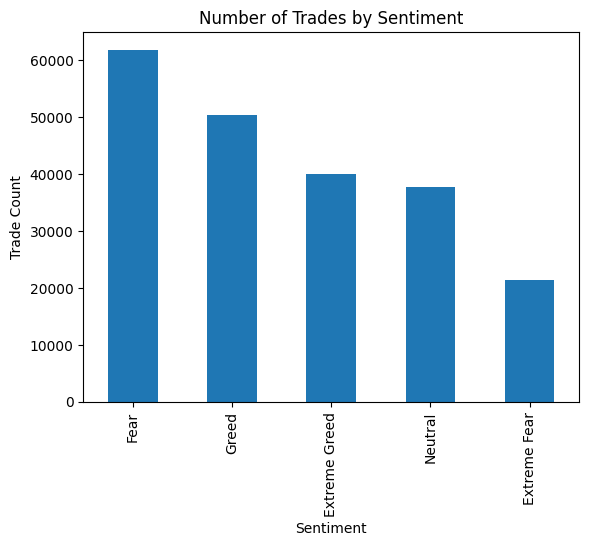

In [28]:
#1. Trading Activity by Sentiment
import matplotlib.pyplot as plt

merged['classification'].value_counts().plot(
    kind='bar'
)

plt.title(
    'Number of Trades by Sentiment'
)

plt.xlabel('Sentiment')
plt.ylabel('Trade Count')

plt.show()

In [ ]:
#INSIGHTS:Fear periods recorded the highest trading activity with 61,837 trades,
# while Extreme Fear periods recorded the lowest activity with 21,400 trades.

In [29]:
merged['classification'].value_counts()

,count
classification,
Fear,61837
Greed,50303
Extreme Greed,39992
Neutral,37686
Extreme Fear,21400


In [30]:
profit_analysis = merged.groupby(
    'classification'
)['Closed PnL'].agg(
    ['count','sum','mean','median']
)

profit_analysis

,count,sum,mean,median
classification,,,,
Extreme Fear,21400,7.391102e+05,34.537862,0.0
Extreme Greed,39992,2.715171e+06,67.892861,0.0
Fear,61837,3.357155e+06,54.290400,0.0
Greed,50303,2.150129e+06,42.743559,0.0
Neutral,37686,1.292921e+06,34.307718,0.0


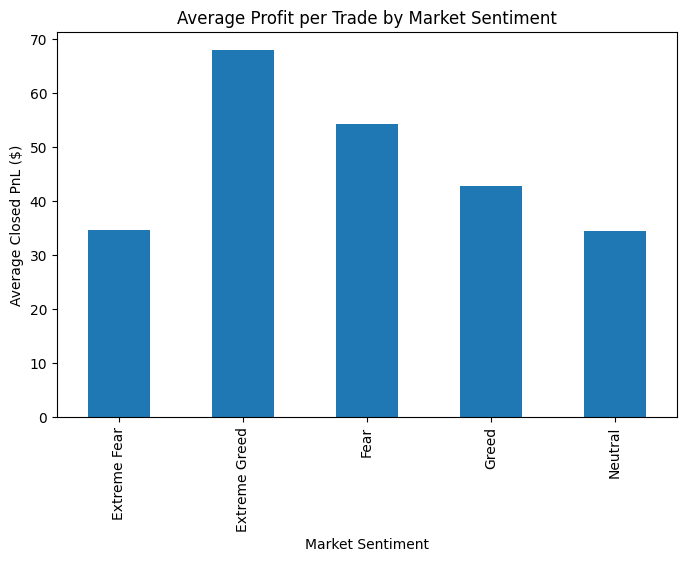

In [31]:
#2. Profitability Analysis
import matplotlib.pyplot as plt

profit_analysis['mean'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Average Profit per Trade by Market Sentiment'
)

plt.ylabel('Average Closed PnL ($)')
plt.xlabel('Market Sentiment')

plt.show()

In [ ]:
#INSIGHTS:Fear periods generated the highest cumulative profit of approximately $3.36 million.
#Extreme Greed generated the highest average profit per trade at approximately $67.89.

In [32]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = (
    merged.groupby('classification')['win']
    .mean()*100
)

win_rate

,win
classification,
Extreme Fear,37.060748
Extreme Greed,46.494299
Fear,42.076750
Greed,38.482794
Neutral,39.699093


In [33]:
win_rate

,win
classification,
Extreme Fear,37.060748
Extreme Greed,46.494299
Fear,42.076750
Greed,38.482794
Neutral,39.699093


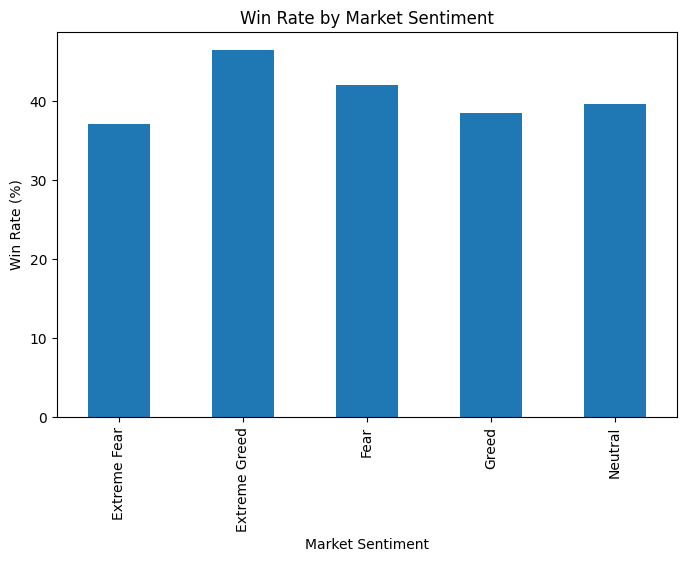

In [34]:
#3. Win Rate Analysis
win_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title(
    'Win Rate by Market Sentiment'
)

plt.ylabel('Win Rate (%)')
plt.xlabel('Market Sentiment')

plt.show()

In [ ]:
#INSIGHTS:Extreme Greed recorded the highest win rate of 46.49%.
#Extreme Fear recorded the lowest win rate of 37.06%.
#This suggests that trend-following strategies perform more effectively during highly optimistic market conditions.

In [35]:
#4. Position Sizing Behavior
trade_size = merged.groupby(
    'classification'
)['Size USD'].agg(
    ['mean','median']
)

trade_size

,mean,median
classification,,
Extreme Fear,5349.731843,766.150
Extreme Greed,3112.251565,500.050
Fear,7816.109931,735.960
Greed,5736.884375,555.000
Neutral,4782.732661,547.655


In [ ]:
#INSIGHTS:Average trade size was highest during Fear periods at approximately $7,816.

#This indicates traders were willing to allocate larger amounts of capital during pessimistic market conditions, consistent with a contrarian accumulation strategy.

In [36]:
#5. Top Trader Performance
top_traders = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
)

top_traders.head(10)

,Closed PnL
Account,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1,8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd,4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713,4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,3.790954e+05


In [ ]:
#INSIGHTS:The most profitable trader generated approximately $2.14 million in realized profits.

#Several other traders generated profits exceeding $800,000, indicating substantial performance differences among market participants.